# Likelihood cost per site: marginalized vs. EMAT

Wall-clock time of every `calculateLogP` call over 100'000 samples, divided by the number of sites. Each method gets the entire alignment (`*_beauti` and `*_emat`, with the single-threaded `TreeLikelihood`). The Ebola marginalized run was stopped at 10'000 samples.

In [35]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
sns.set_style("darkgrid")

# the run outputs live in the tests directory at the repository root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tests" / "hcv_emat.xml").exists())
TESTS_PATH = ROOT / "tests"

# the first evaluations are dominated by JIT compilation and are dropped
WARMUP_FRACTION = 0.1

# the run whose timing file holds each method, per experiment
experiment_runs = {
    "ebola": {"marginalized": "ebola_beauti", "EMAT": "ebola_emat"},
    "hcv": {"marginalized": "hcv_beauti", "EMAT": "hcv_emat"},
    "zika": {"marginalized": "zika_beauti", "EMAT": "zika_emat"},
}
experiments = list(experiment_runs)

method_files = {"marginalized": "marginalized", "EMAT": "emat"}
method_colors = {"marginalized": "C1", "EMAT": "C0"}
methods = list(method_files)

In [37]:
def read_timings(experiment: str, method: str) -> tuple[pd.DataFrame, dict] | None:
    """Read the per-evaluation timings of one distribution and the size of its alignment from the header."""
    path = TESTS_PATH / f"{experiment_runs[experiment][method]}_timing_{method_files[method]}.csv"
    if not path.exists():
        print(f"no timings found for {experiment} {method}")
        return None

    header = {}
    with open(path) as file:
        for line in file:
            if not line.startswith("#"):
                break
            key, value = line[1:].strip().split("=")
            header[key] = value

    labels = {"experiment": experiment, "method": method}
    sizes = {**labels, **{key: int(header[key]) for key in ["sites", "patterns", "taxa"]}}

    timings_df = pd.read_csv(path, comment="#")
    timings_df = timings_df.iloc[int(len(timings_df) * WARMUP_FRACTION):].copy()
    timings_df = timings_df.assign(**labels)
    timings_df["microseconds"] = timings_df["nanoseconds"] / 1e3
    timings_df["microseconds_per_site"] = timings_df["microseconds"] / sizes["sites"]
    timings_df["microseconds_per_pattern"] = timings_df["microseconds"] / sizes["patterns"]

    return timings_df, sizes


timings = [read_timings(experiment, method) for experiment in experiments for method in methods]
timings = [timing for timing in timings if timing is not None]
timings_df = pd.concat([df for df, _ in timings], ignore_index=True)
sizes_df = pd.DataFrame([sizes for _, sizes in timings]).set_index(["experiment", "method"])
sizes_df

sites  patterns  taxa
experiment method                             
ebola      marginalized  18996      7930  1610
           EMAT          18996      7930  1610
hcv        marginalized    411       246    63
           EMAT            411       246    63
zika       marginalized  10807      3007   174
           EMAT          10807      3007   174

In [38]:
# the mean and median cost of one evaluation, in total and per site and pattern
summary_df = timings_df.groupby(["experiment", "method"]).agg(
    num_evaluations=("microseconds", "size"),
    mean_microseconds=("microseconds", "mean"),
    median_microseconds=("microseconds", "median"),
    mean_microseconds_per_site=("microseconds_per_site", "mean"),
    median_microseconds_per_site=("microseconds_per_site", "median"),
    mean_microseconds_per_pattern=("microseconds_per_pattern", "mean"),
    total_seconds=("microseconds", lambda microseconds: microseconds.sum() / 1e6),
)
summary_df.round(4)

num_evaluations  mean_microseconds  \
experiment method                                             
ebola      EMAT                    67217            34.6387   
           marginalized             6713         88732.2036   
hcv        EMAT                    69349             1.6546   
           marginalized            59742            16.9332   
zika       EMAT                    72837             3.1629   
           marginalized            74925           397.2018   

                         median_microseconds  mean_microseconds_per_site  \
experiment method                                                          
ebola      EMAT                       24.667                      0.0018   
           marginalized            79139.375                      4.6711   
hcv        EMAT                        0.750                      0.0040   
           marginalized               17.208                      0.0412   
zika       EMAT                        1.750                      0.0003   
           marginalized              224.958                      0.0368   

                         median_microseconds_per_site  \
experiment method                                       
ebola      EMAT                                0.0013   
           marginalized                        4.1661   
hcv        EMAT                                0.0018   
           marginalized                        0.0419   
zika       EMAT                                0.0002   
           marginalized                        0.0208   

                         mean_microseconds_per_pattern  total_seconds  
experiment method                                                      
ebola      EMAT                                 0.0044         2.3283  
           marginalized                        11.1894       595.6593  
hcv        EMAT                                 0.0067         0.1147  
           marginalized                         0.0688         1.0116  
zika       EMAT                                 0.0011         0.2304  
           marginalized                         0.1321        29.7603

In [39]:
# how many times faster an EMAT site is evaluated than a marginalized site, by the mean cost per site
speedups = {
    experiment: summary_df.loc[(experiment, "marginalized"), "mean_microseconds_per_site"]
    / summary_df.loc[(experiment, "EMAT"), "mean_microseconds_per_site"]
    for experiment in experiments
    if all((experiment, method) in summary_df.index for method in methods)
}
pd.Series(speedups, name="speed-up").round(1)

ebola    2561.6
hcv        10.2
zika      125.6
Name: speed-up, dtype: float64

In [44]:
def plot_speedups():
    """Plot the mean cost per site with the speed-up, and its distribution over evaluations, for every experiment."""
    plotted_experiments = [experiment for experiment in experiments if experiment in speedups]
    fig, axes = plt.subplots(len(plotted_experiments), 2, figsize=(7, 2.5 * len(plotted_experiments)), squeeze=False)

    for (ax_bar, ax_hist), experiment in zip(axes, plotted_experiments):
        experiment_summary = summary_df.loc[experiment].loc[methods]
        experiment_sizes = sizes_df.loc[experiment]
        speedup = speedups[experiment]

        # left: mean cost per site with the median as a marker

        means = experiment_summary["mean_microseconds_per_site"].values
        medians = experiment_summary["median_microseconds_per_site"].values
        ax_bar.bar(methods, means, color=[method_colors[method] for method in methods])
        ax_bar.scatter(methods, medians, color="black", marker="_", s=400, zorder=3, label="median")
        for x, mean in enumerate(means):
            ax_bar.annotate(f"{mean:.3g} µs", (x, mean), ha="center", va="bottom", xytext=(0, 3), textcoords="offset points")

        # an arrow from the slower to the faster bar, labelled with the speed-up of EMAT

        slow, fast = (0, 1) if means[0] >= means[1] else (1, 0)
        ax_bar.annotate(
            "", xy=(fast, means[fast]), xytext=(slow, means[slow]),
            arrowprops=dict(arrowstyle="->", color="black", linewidth=1.5, shrinkA=12, shrinkB=12, connectionstyle="arc3,rad=-0.3"),
        )
        label = f"{speedup:,.0f}× faster" if speedup >= 1 else f"{1 / speedup:,.1f}× slower"
        ax_bar.text(
            0.5, (means[0] * means[1]) ** 0.5, f"EMAT {label}",
            ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="round", facecolor="white"),
        )

        ax_bar.set_yscale("log")
        ax_bar.set_ylim(means.min() / 3, means.max() * 5)
        ax_bar.set_ylabel("µs per site per evaluation")
        ax_bar.set_xticks(range(len(methods)), [f"{method}\n({experiment_sizes.loc[method, 'sites']} sites)" for method in methods])
        ax_bar.set_title(f"{experiment}: mean cost per site")
        ax_bar.legend(loc="upper right")

        # right: distribution of the cost per site over all evaluations

        experiment_timings_df = timings_df[timings_df.experiment == experiment]
        sns.histplot(
            experiment_timings_df, x="microseconds_per_site", hue="method", hue_order=methods,
            palette=method_colors, log_scale=True, stat="probability", common_norm=False, element="step", bins=80, ax=ax_hist,
        )
        ax_hist.set_xlabel("µs per site per evaluation")
        ax_hist.set_ylabel("share of evaluations")
        ax_hist.set_title(f"{experiment}: distribution over evaluations")

    fig.tight_layout()
    plt.show()

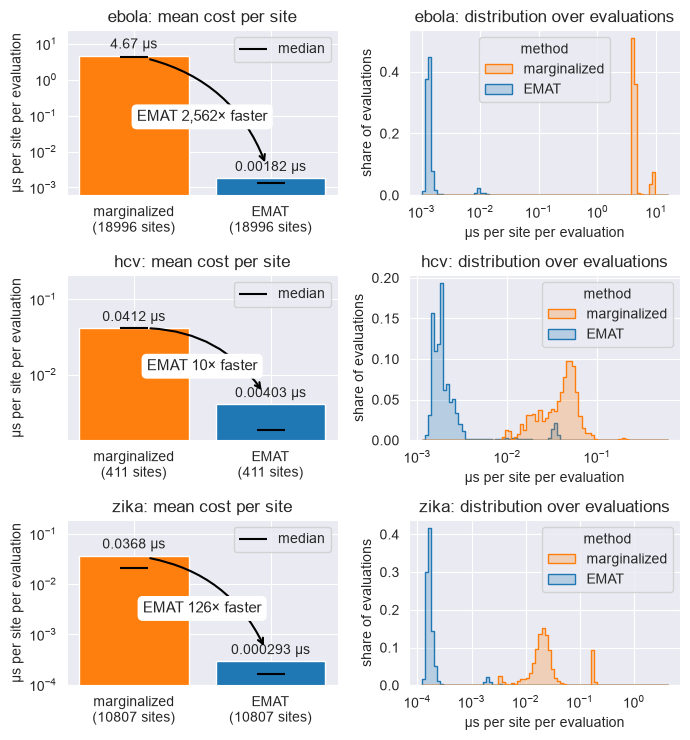

In [45]:
plot_speedups()

Caveats:

- No BEAGLE; `TreeLikelihood` also profits from repeated patterns.
- Both likelihoods recompute incrementally, so this is the cost per MCMC step, which depends on the operators.
- EMAT cost scales with branches and mutations, not sites.
- Operator time (e.g. Gibbs, mutation-time moves) is not included.